# Spherical Spline Interpolation Baseline
## 1. Setup and Utilities
This notebook runs spherical spline interpolation directly using MNE and saves outputs in this folder.

## Notebook Flow
1. Configure paths and parameters.
2. Define reusable helper functions.
3. Train/evaluate the method on LOSO splits.
4. Save metrics (CSV/JSON) and plot artifacts (PNG) in this folder.

## 2. Data, Utilities, and Method Definition
This section defines constants, helper functions, and model architecture used by the benchmark.

In [1]:
# --- 1) Imports and core setup ---
# This section centralizes dependencies, path discovery, and run configuration.
# Keeping setup here makes the remaining cells method-focused and easier to debug.

from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mne.channels import make_standard_montage
from mne.channels.interpolation import _make_interpolation_matrix

def find_repo_root(start: Path) -> Path:
    # Locate repository root by scanning parent directories.
    for candidate in [start, *start.parents]:
        if (candidate / 'processed').exists() and (candidate / 'Main_codes').exists():
            return candidate
    raise RuntimeError('Could not locate repository root.')

REPO_ROOT = find_repo_root(Path.cwd().resolve())
NOTEBOOK_DIR = REPO_ROOT / 'Main_codes' / 'Baseline_analysis' / 'Interpolation_methods' / 'spherical_spline'
NOTEBOOK_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR = REPO_ROOT / 'processed' / 'bci_competition_iv_2a'

CHANNELS_22 = [
    'Fz','FC3','FC1','FCz','FC2','FC4','C5','C3','C1','Cz','C2','C4',
    'C6','CP3','CP1','CPz','CP2','CP4','P1','Pz','P2','POz'
]
CHANNEL_SET_5 = ['Fz', 'C3', 'C4', 'Pz', 'POz']
CHANNEL_SET_10 = ['Fz', 'FC3', 'FC4', 'C3', 'Cz', 'C4', 'CP3', 'CP4', 'Pz', 'POz']
CHANNEL_SET_15 = ['Fz', 'FC3', 'FC1', 'FC2', 'FC4', 'C3', 'C1', 'Cz', 'C2', 'C4', 'CP3', 'CP1', 'CP2', 'CP4', 'Pz']

def load_subject_data(subject_dir: Path):
    # Load one subject's preprocessed EEG trials and labels from NPZ.
    npz = np.load(subject_dir / 'trials.npz', allow_pickle=True)
    return npz['X'].astype(np.float32), npz['y'].astype(np.int32)

def to_sample_matrix(trials_ch_time):
    # Reshape trial-wise EEG to sample-wise matrix for model training/evaluation.
    n_trials, n_channels, n_times = trials_ch_time.shape
    return np.transpose(trials_ch_time, (0, 2, 1)).reshape(n_trials * n_times, n_channels)

def get_spherical_positions(channels):
    # Fetch normalized 3D channel coordinates from standard montage.
    montage = make_standard_montage('standard_1005')
    ch_pos = montage.get_positions()['ch_pos']
    pos = []
    for ch in channels:
        p = np.asarray(ch_pos[ch], dtype=np.float64)
        p = p / max(np.linalg.norm(p), 1e-12)
        pos.append(p)
    return np.stack(pos, axis=0)

_CACHE = {}
def spherical_spline_interpolation(X_input, input_channels, target_channels):
    # Interpolate missing channels with spherical spline projection matrix.
    key = (tuple(input_channels), tuple(target_channels))
    if key not in _CACHE:
        pos_from = get_spherical_positions(input_channels)
        pos_to = get_spherical_positions(target_channels)
        _CACHE[key] = _make_interpolation_matrix(pos_from, pos_to)
    mat = _CACHE[key]
    return X_input @ mat.T

def compute_metrics(y_true, y_pred):
    # Compute reconstruction fidelity metrics (RMSE, MAE, Pearson r, R2).
    diff = y_true - y_pred
    rmse = float(np.sqrt(np.mean(diff ** 2)))
    mae = float(np.mean(np.abs(diff)))
    yt = y_true.reshape(-1)
    yp = y_pred.reshape(-1)
    yt_c = yt - yt.mean()
    yp_c = yp - yp.mean()
    den = np.sqrt(np.sum(yt_c ** 2) * np.sum(yp_c ** 2))
    pearson_r = float(np.sum(yt_c * yp_c) / den) if den > 0 else np.nan
    ss_res = float(np.sum((yt - yp) ** 2))
    ss_tot = float(np.sum((yt - yt.mean()) ** 2))
    r2 = float(1.0 - ss_res / ss_tot) if ss_tot > 0 else np.nan
    return {'rmse': rmse, 'mae': mae, 'pearson_r': pearson_r, 'r2': r2}

MAX_SPLITS = 0
loso_splits = json.loads((PROCESSED_DIR / 'loso_splits.json').read_text(encoding='utf-8'))
if MAX_SPLITS > 0:
    loso_splits = loso_splits[:MAX_SPLITS]

## 3. LOSO Training and Evaluation
This section runs subject-wise train/test evaluation and computes reconstruction metrics.

In [2]:
rows = []
for split in loso_splits:
    test_subject = split['test_subject']
    x_test_trials, _ = load_subject_data(PROCESSED_DIR / test_subject)
    test_samples = to_sample_matrix(x_test_trials)
    for input_channels in [CHANNEL_SET_5, CHANNEL_SET_10, CHANNEL_SET_15]:
        input_idx = [CHANNELS_22.index(c) for c in input_channels]
        missing_channels = [c for c in CHANNELS_22 if c not in input_channels]
        missing_idx = [CHANNELS_22.index(c) for c in missing_channels]
        X_input = test_samples[:, input_idx]
        Y_true = test_samples[:, missing_idx]
        Y_pred = spherical_spline_interpolation(X_input, input_channels, missing_channels)
        metrics = compute_metrics(Y_true, Y_pred)
        rows.append({
            'test_subject': test_subject,
            'n_input_channels': len(input_channels),
            'input_channels': ','.join(input_channels),
            'n_reconstructed_channels': len(missing_channels),
            'method': 'spherical_spline_interpolation',
            **metrics,
            'n_test_samples': int(test_samples.shape[0]),
        })
df = pd.DataFrame(rows)
df.head()

,test_subject,n_input_channels,input_channels,n_reconstructed_channels,method,rmse,mae,pearson_r,r2,n_test_samples
0,A01T,5,"Fz,C3,C4,Pz,POz",17,spherical_spline_interpolation,2.685463,2.018788,0.964393,0.928820,273000
1,A01T,10,"Fz,FC3,FC4,C3,Cz,C4,CP3,CP4,Pz,POz",12,spherical_spline_interpolation,2.153433,1.607595,0.977380,0.954017,273000
2,A01T,15,"Fz,FC3,FC1,FC2,FC4,C3,C1,Cz,C2,C4,CP3,CP1,CP2,...",7,spherical_spline_interpolation,3.098630,2.221028,0.951323,0.897467,273000
3,A02T,5,"Fz,C3,C4,Pz,POz",17,spherical_spline_interpolation,2.320647,1.722416,0.964908,0.930282,270000
4,A02T,10,"Fz,FC3,FC4,C3,Cz,C4,CP3,CP4,Pz,POz",12,spherical_spline_interpolation,2.199501,1.565799,0.968838,0.937547,270000


## 4. Export Metrics and Visualizations
This section writes CSV/JSON summaries and saves plot artifacts to the method folder.

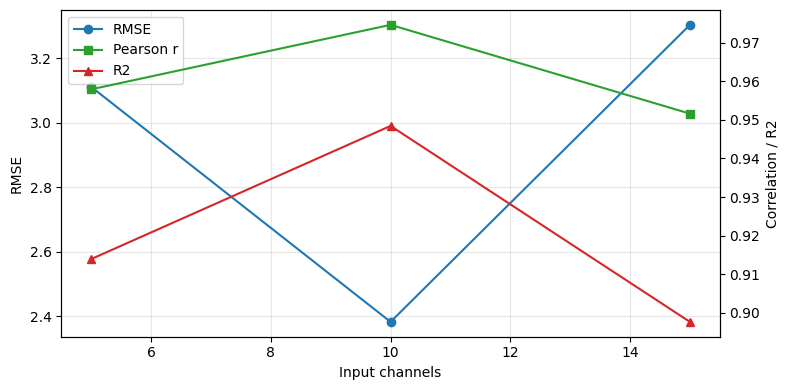

Saved: E:\Github\EEGFeatureExtraction\Main_codes\Baseline_analysis\Interpolation_methods\spherical_spline\spherical_spline_metrics.csv
Saved: E:\Github\EEGFeatureExtraction\Main_codes\Baseline_analysis\Interpolation_methods\spherical_spline\spherical_spline_summary.json
Saved: E:\Github\EEGFeatureExtraction\Main_codes\Baseline_analysis\Interpolation_methods\spherical_spline\spherical_spline_metrics_plot.png


In [3]:
output_csv = NOTEBOOK_DIR / 'spherical_spline_metrics.csv'
output_json = NOTEBOOK_DIR / 'spherical_spline_summary.json'
plot_path = NOTEBOOK_DIR / 'spherical_spline_metrics_plot.png'
df.to_csv(output_csv, index=False)
summary = df.groupby('n_input_channels', as_index=False)[['rmse', 'mae', 'pearson_r', 'r2']].mean()
payload = {'rows': int(len(df)), 'splits': int(len(loso_splits)), 'method': 'spherical_spline_interpolation', 'mean_metrics': summary.to_dict(orient='records')}
output_json.write_text(json.dumps(payload, indent=2), encoding='utf-8')
fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.plot(summary['n_input_channels'], summary['rmse'], marker='o', label='RMSE')
ax1.set_xlabel('Input channels')
ax1.set_ylabel('RMSE')
ax1.grid(True, alpha=0.3)
ax2 = ax1.twinx()
ax2.plot(summary['n_input_channels'], summary['pearson_r'], marker='s', color='tab:green', label='Pearson r')
ax2.plot(summary['n_input_channels'], summary['r2'], marker='^', color='tab:red', label='R2')
ax2.set_ylabel('Correlation / R2')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='best')
fig.tight_layout()
fig.savefig(plot_path, dpi=150)
plt.show()
print('Saved:', output_csv)
print('Saved:', output_json)
print('Saved:', plot_path)